# Palmer Penguins: Exploratory Data Analysis

By Cory Shockley
Python • Pandas • Seaborn • SciPy




### **Introduction**

This project explores the **Palmer Penguins** dataset for practicing exploratory data analysis (EDA). The dataset contains physical measurements of three penguin species — _Adelie, Chinstrap, and Gentoo_ — collected from three islands in the Palmer Archipelago of Antarctica.

**The goal of this analysis is to:**
- understand the structure and quality of the dataset
- explore distributions of key biological measurements
- examine relationships between variables
- identify species‑level differences
- evaluate how island and sex relate to physical traits
- practice core EDA techniques aligned with CompTIA Data+ objectives

This project demonstrates a complete EDA workflow, including data inspection, missingness analysis, univariate and bivariate exploration, visualization, and interpretation. The analysis is written to be clear, reproducible, and suitable for a professional portfolio.

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### **Data Overview**

The dataset contains _344_ rows and _8_ variables:

- **species** — penguin species (categorical)
- **island** — island where the penguin was observed (categorical)
- **bill_length_mm** — bill length in millimeters (numeric)
- **bill_depth_mm** — bill depth in millimeters (numeric)
- **flipper_length_mm** — flipper length in millimeters (numeric)
- **body_mass_g** — body mass in grams (numeric)
- **sex** — penguin sex (categorical)
- **year** — year of observation (numeric)

Initial inspection _(df.info()_ and _df.describe())_ shows:

- numeric variables are clean and correctly typed
- categorical variables are stored as strings (object dtype)
- missing values occur in five variables
- missingness is low overall, but meaningful in the sex column

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [83]:
df.describe(include="all")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,344,344,342.000000,342.000000,342.000000,342.000000,333,344.000000
unique,3,3,NaN,NaN,NaN,NaN,2,NaN
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,male,NaN
freq,152,168,NaN,NaN,NaN,NaN,168,NaN
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN,2008.029070
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN,0.818356
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN,2007.000000
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN,2007.000000
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN,2008.000000
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN,2009.000000


### **Missingness Analysis**

Missing values were quantified using _df.isna().sum()_ and _df.isna().mean()_.

Key findings:

- Four numeric variables each have **2 missing values** (~0.6%)
- The sex variable has **11 missing values** (~3.2%)
- Species, island, and year have **no missing values**

The numeric missingness is minimal and does not meaningfully affect the dataset. These rows can be safely dropped when performing numeric‑only analysis.

However, the missing values in the sex column require a different approach. Sex is not needed for species‑level or island‑level analysis, but it is required for sex‑based comparisons. Dropping these rows early would unnecessarily reduce the dataset and remove individuals that are still useful for other analyses.

**Therefore, the missing sex values are retained until the point where sex‑specific analysis is performed.**

At that stage, rows with missing sex will be excluded only for those specific calculations.

This approach preserves data integrity while maintaining flexibility across different analytical questions.

In [84]:
# Review missingness
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [85]:
# Missingness percent
percent_missing = df.isna().mean().round(3) * 100
print(percent_missing)

species              0.0
island               0.0
bill_length_mm       0.6
bill_depth_mm        0.6
flipper_length_mm    0.6
body_mass_g          0.6
sex                  3.2
year                 0.0
dtype: float64


### **Univariate Analysis**

Univariate analysis examines each variable independently to understand its distribution, range, and overall behavior. This step helps identify patterns, potential data quality issues, and early insights before exploring relationships between variables.

#### **Categorical Variables**

**Species Distribution**

The dataset includes three penguin species:
- Adelie
- Chinstrap
- Gentoo
-
A simple count of species shows how balanced the dataset is and whether any species dominate the sample.

**Island Distribution**

Penguins were observed on three islands:

- Biscoe
- Dream
- Torgersen
-
Understanding island distribution helps reveal sampling structure and prepares for later analysis of species–island relationships.

**Sex Distribution**

The sex variable contains two categories:

- male
- female
-
However, 11 values are missing. These missing values are intentionally retained at this stage because sex is not required for species‑level or island‑level analysis. Removing these rows prematurely would reduce the dataset unnecessarily and remove individuals that are still useful for other analyses.

Sex‑based analysis will be performed later, and missing values will be excluded only for those specific calculations.

**Numeric Variables**

The numeric variables include:

- bill_length_mm
- bill_depth_mm
- flipper_length_mm
- body_mass_g
- year
-
Univariate analysis of numeric variables focuses on:

- central tendency (median)
- spread (IQR, range)
- outliers
- distribution shape
-
These characteristics will be explored visually using boxplots and KDEs in later sections.

In [86]:
# Species count
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [87]:
# Island count
df["island"].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [88]:
# Sex count
df["sex"].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

Text(0, 0.5, 'Frequency')

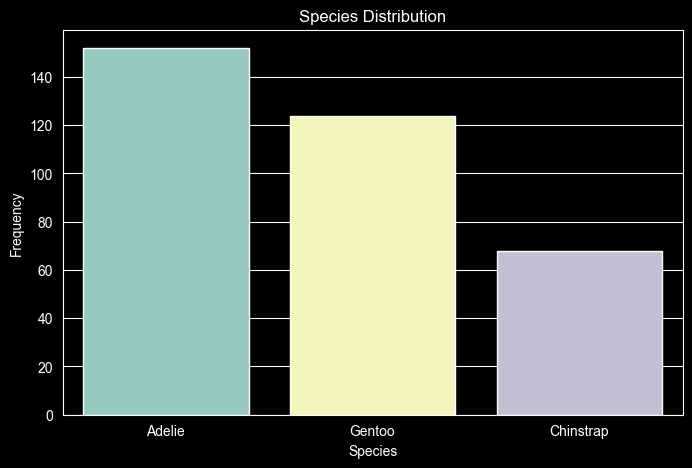

In [89]:
# Species distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="species", hue="species")
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

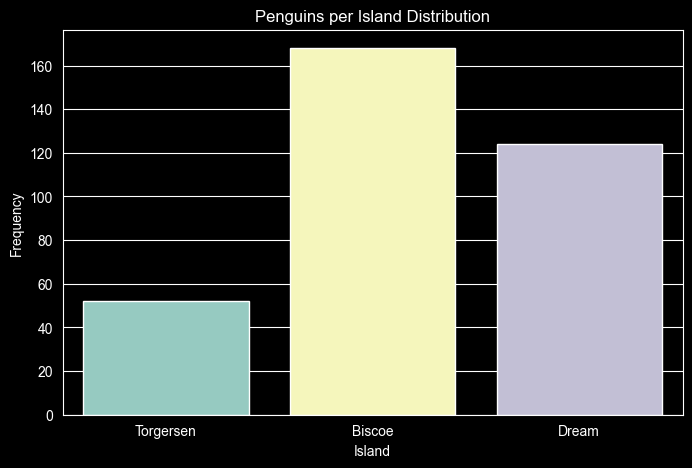

In [90]:
# Penguins per Island Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="island", hue="island")
plt.title("Penguins per Island Distribution")
plt.xlabel("Island")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

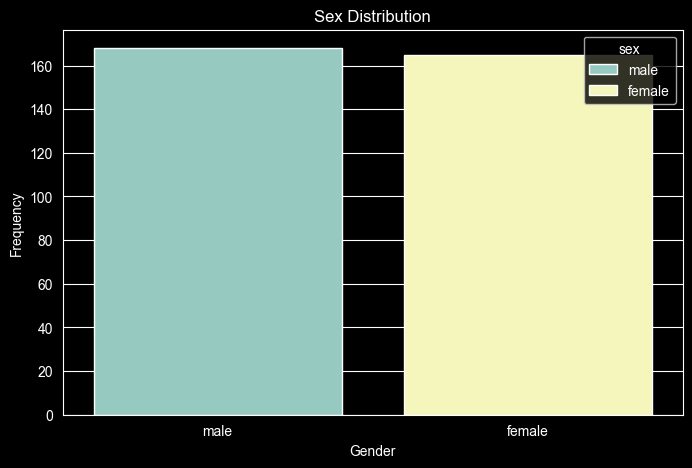

In [91]:
# Sex distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="sex", hue="sex")
plt.title("Sex Distribution")
plt.xlabel("Gender")
plt.ylabel("Frequency")

### **Bivariate Analysis**

Bivariate analysis explores how two variables relate to each other. This helps identify patterns, group differences, and potential predictors. In this dataset, the most important relationships involve:

- **species × island** (categorical vs categorical)
- **species × numeric variables** (categorical vs numeric)
- **numeric × numeric relationships** (correlations and distributions)

1. **Species × Island**
A crosstab and countplot show how species are distributed across islands.

Key findings:
- **Gentoo** penguins appear only on **Biscoe**
- **Chinstrap** penguins appear only on **Dream**
- **Adelie** penguins appear on **all three islands**

This means the imbalance is **structural**, not random. Species and island are strongly associated.

2. **Species × Numeric Variables**

Boxplots compare numeric measurements across species. These reveal:
- **Gentoo** penguins are consistently larger (body mass, flipper length)
- **Adelie** and **Chinstrap** overlap in some traits
- Bill measurements show strong species separation

These patterns match the species clusters seen in the pairplot.

3. **Numeric × Numeric Relationships**

Three visualizations were used to explore relationships between numeric variables:

**a. Pairplot (species × bill length × bill depth × flipper length × body mass)**

The pairplot shows:
- clear species clusters
- strong positive relationships (e.g., flipper length ↔ body mass)
- negative relationships (e.g., bill depth ↔ flipper length)
- distribution shapes on the diagonal

This is one of the most information‑dense views of the dataset.

**b. Histplot (body mass, hue = species, KDE = True)**

This plot shows:
- Gentoo penguins dominate the right tail (heavier)
- Adelie and Chinstrap overlap more
- KDE curves reveal smooth distribution shapes for each species

This complements the boxplot by showing the shape of the distribution.

**c. Correlation Heatmap**

The heatmap quantifies the relationships seen in the pairplot:
- **Flipper length ↔ body mass**: very strong positive correlation
- **Bill length ↔ flipper length**: moderate positive correlation
- **Bill depth ↔ other measurements**: negative correlations
- **Year**: no meaningful correlation with physical traits

Together, these visuals confirm the biological structure of the dataset.

In [92]:
# Species x Island Crosstab

pd.crosstab(df["species"], df["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


Text(0, 0.5, 'Frequency')

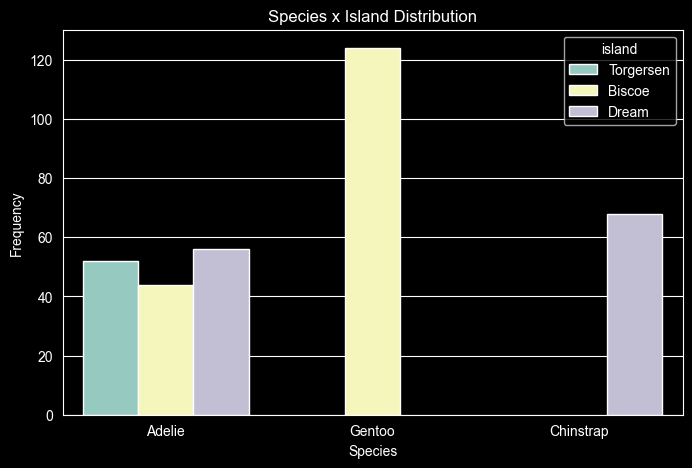

In [93]:
# Species x Island Countplot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="species", hue="island")
plt.title("Species x Island Distribution")
plt.xlabel("Species")
plt.ylabel("Frequency")

Text(0, 0.5, 'Body Mass (g)')

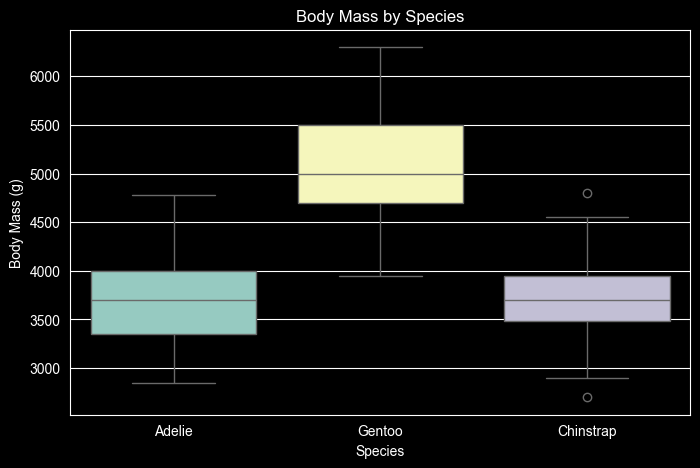

In [94]:
# Species x Body Mass Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="species", y="body_mass_g", hue="species")
plt.title("Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")

Text(0, 0.5, 'Flipper Length (mm)')

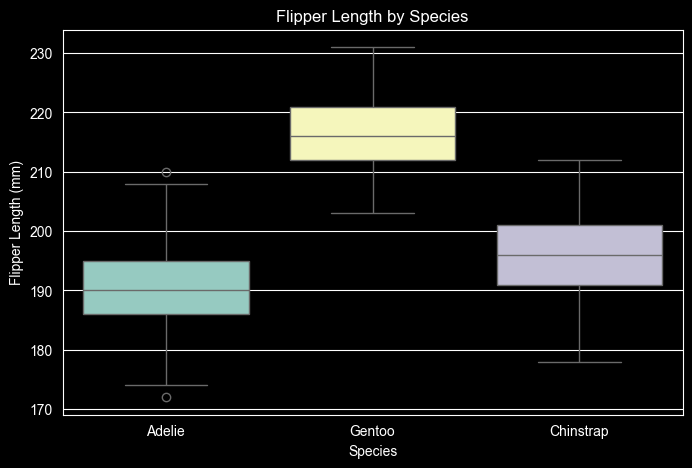

In [95]:
# Species x Flipper Length Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="species", y="flipper_length_mm", hue="species")
plt.title("Flipper Length by Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")

### **Multivariate Analysis**

Multivariate analysis allows....

Text(0.5, 1.0, 'Pair plot')

<Figure size 800x500 with 0 Axes>

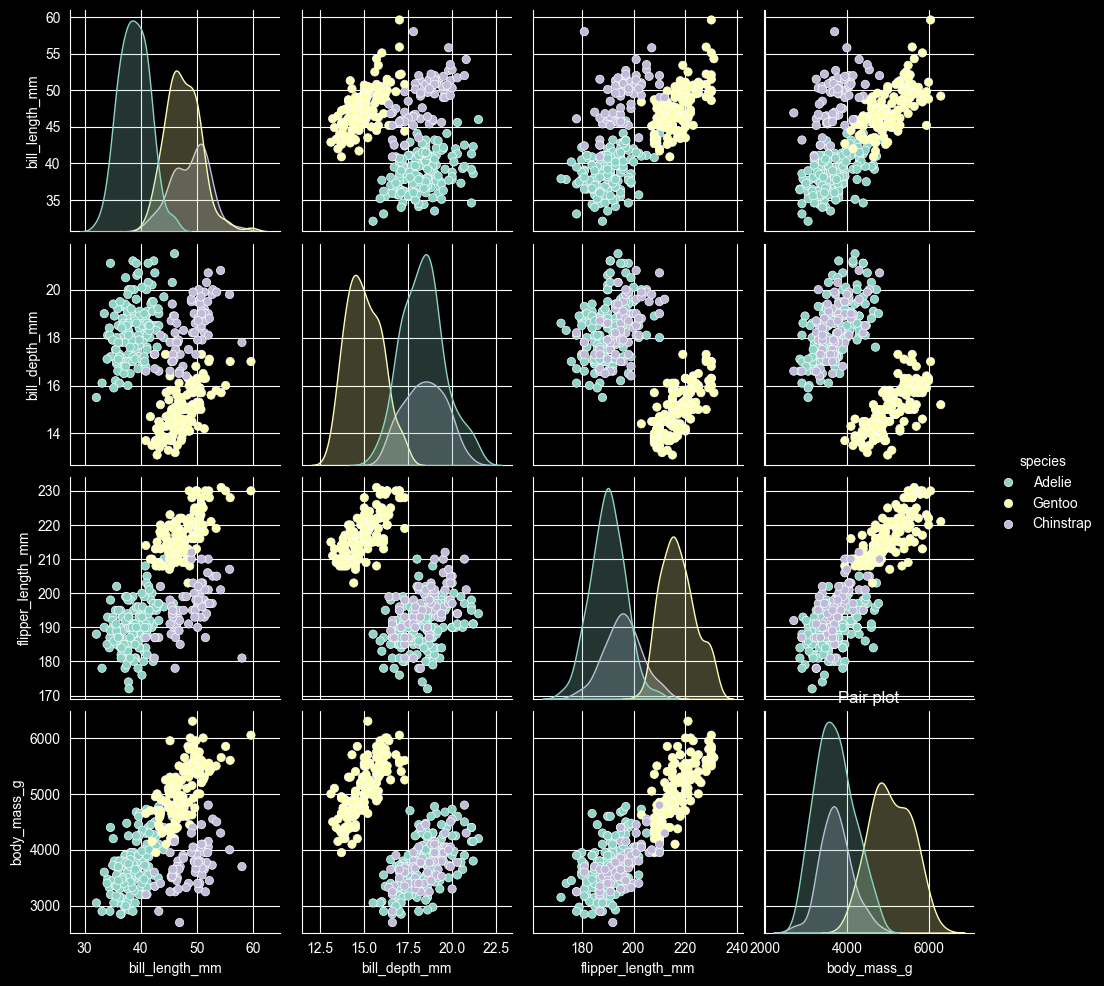

In [109]:
# Pairplot to show possible correlations
plt.figure(figsize=(8,5))
sns.pairplot(data=df, hue="species",
    vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
             )
plt.title("Pair plot")

<Figure size 800x500 with 0 Axes>

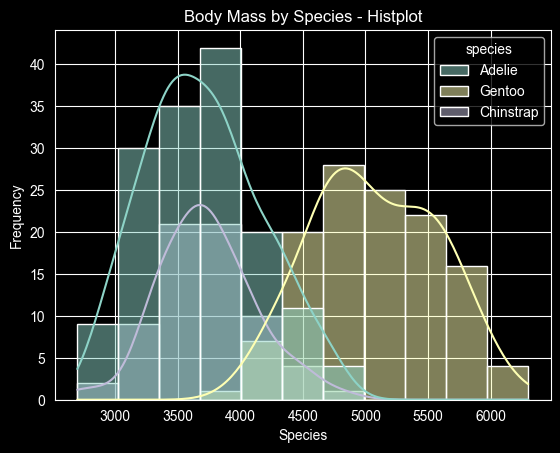

<Figure size 800x500 with 0 Axes>

In [110]:
# Histplot
sns.histplot(data=df, x="body_mass_g", hue="species", kde=True)
plt.title("Body Mass by Species - Histplot")
plt.xlabel("Species")
plt.ylabel("Frequency")
plt.figure(figsize=(8,5))

In [111]:
# Compute correlations
df.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.235053,0.656181,0.595110,0.054545
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916,-0.060354
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202,0.169675
body_mass_g,0.595110,-0.471916,0.871202,1.000000,0.042209
year,0.054545,-0.060354,0.169675,0.042209,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

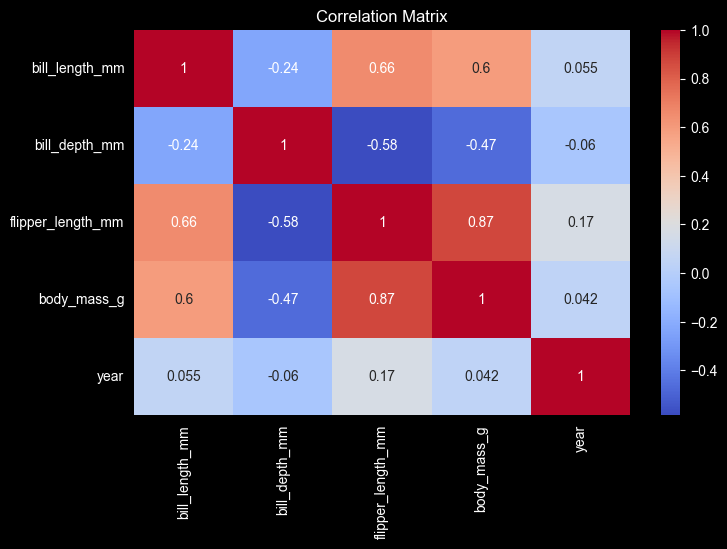

In [112]:
# Visualize correlations
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

### **Sex‑Based Analysis**

The sex variable contains two categories — male and female — along with 11 missing values. Earlier in the analysis, these missing values were intentionally retained because sex was not required for species‑level or island‑level exploration. Removing these rows prematurely would have reduced the dataset unnecessarily and removed individuals still useful for other analyses.

In this section, sex is directly relevant, so rows with missing sex values will be excluded only for the calculations that require sex. This preserves data integrity while ensuring accurate comparisons.

1. Sex Distribution

A simple count of male and female penguins provides an overview of the dataset’s balance. Missing values are included in the count to show the full picture before filtering.

2. Sex × Species

A crosstab and countplot show how sex is distributed within each species. This helps determine whether certain species have more males or females represented in the dataset.

3. Sex × Numeric Variables

Boxplots compare male and female penguins across key physical measurements:

- bill length
- bill depth
- flipper length
- body mass

These visualizations reveal whether males and females differ in size and whether those differences are consistent across traits.

4. Statistical Test: Male vs Female Body Mass

A simple independent‑samples t‑test is used to determine whether male and female penguins differ significantly in body mass. This test is appropriate because:
- body mass is numeric
- sex has two groups
- the groups are independent

This adds an inferential component to the analysis and demonstrates statistical reasoning aligned with CompTIA Data+ objectives.




In [100]:
# Sex distribution
df["sex"].value_counts(dropna=False)

sex
male      168
female    165
NaN        11
Name: count, dtype: int64

In [101]:
# Create new df to filter out missing sex values for sex-based analysis
df_sex = df.dropna(subset=["sex"])

In [102]:
# Sex x species crosstab
pd.crosstab(df_sex["species"], df_sex["sex"])

sex,female,male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


Text(0, 0.5, 'Frequency')

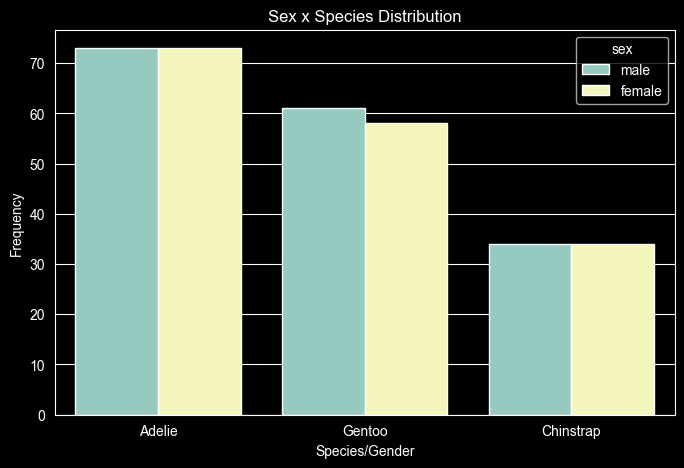

In [103]:
# Sex x species countplot
plt.figure(figsize=(8,5))
sns.countplot(data=df_sex, x="species", hue="sex")
plt.title("Sex x Species Distribution")
plt.xlabel("Species/Gender")
plt.ylabel("Frequency")

Text(0, 0.5, 'Body Mass (g)')

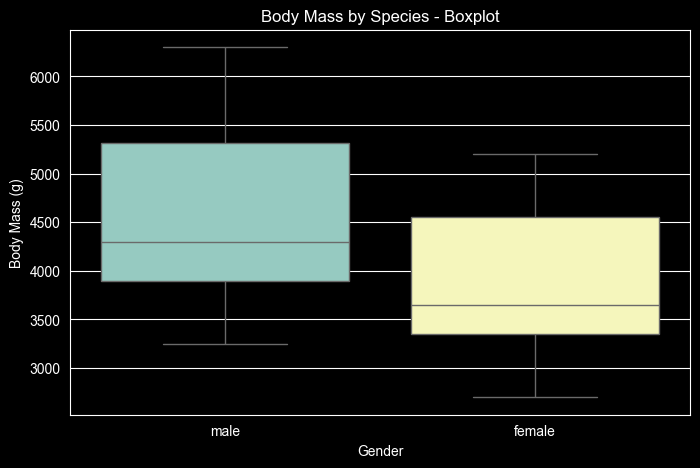

In [104]:
# Sex x body mass boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df_sex, x="sex", y="body_mass_g", hue="sex")
plt.title("Body Mass by Species - Boxplot")
plt.xlabel("Gender")
plt.ylabel("Body Mass (g)")

Text(0, 0.5, 'Flipper Length (mm)')

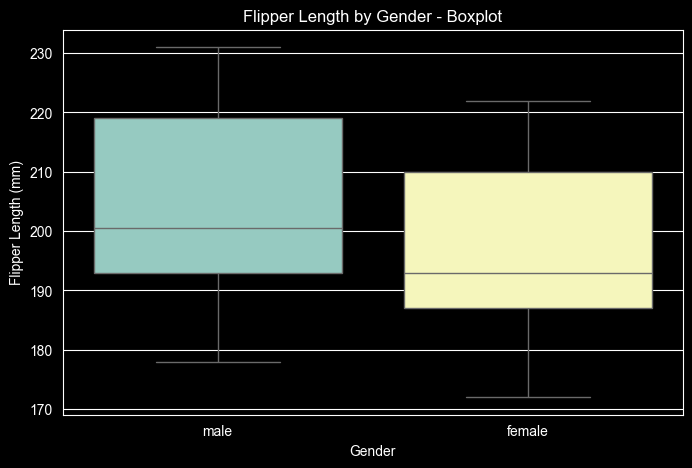

In [105]:
# Sex x flipper length boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df_sex, x="sex", y="flipper_length_mm", hue="sex")
plt.title("Flipper Length by Gender - Boxplot")
plt.xlabel("Gender")
plt.ylabel("Flipper Length (mm)")

Text(0, 0.5, 'Bill Length (mm)')

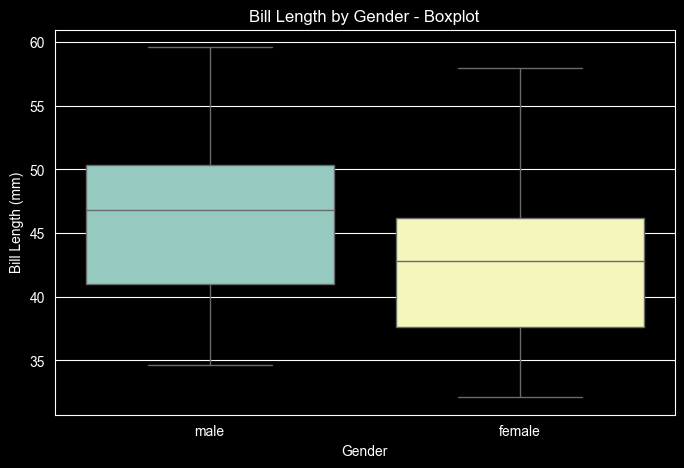

In [106]:
# Sex x bill length boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df_sex, x="sex", y="bill_length_mm", hue="sex")
plt.title("Bill Length by Gender - Boxplot")
plt.xlabel("Gender")
plt.ylabel("Bill Length (mm)")

Text(0, 0.5, 'Bill Depth (mm)')

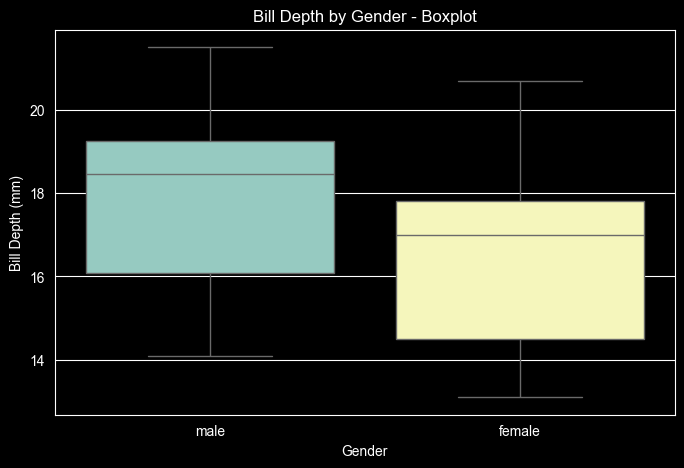

In [107]:
# Sex x bill depth boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df_sex, x="sex", y="bill_depth_mm", hue="sex")
plt.title("Bill Depth by Gender - Boxplot")
plt.xlabel("Gender")
plt.ylabel("Bill Depth (mm)")

In [108]:
# T-test: male x female body mass

from scipy.stats import ttest_ind

male_mass = df_sex[df_sex["sex"] == "male"]["body_mass_g"]
female_mass = df_sex[df_sex["sex"] == "female"]["body_mass_g"]

ttest_ind(male_mass, female_mass, nan_policy="omit")

TtestResult(statistic=np.float64(8.541720337994516), pvalue=np.float64(4.897246751596224e-16), df=np.float64(331.0))

**Statistical Test: Male vs Female Body Mass**

An independent‑samples t‑test was conducted to determine whether male and female penguins differ in body mass. The results show a **very large t‑statistic (t = 8.54)** and an extremely small **p‑value (p = 4.9 × 10⁻¹⁶)**. This indicates that the difference in mean body mass between males and females is **highly statistically significant**. Male penguins are, on average, heavier than female penguins. This finding aligns with known biological patterns of sexual dimorphism in penguins.



### **Key Insights**

This exploratory data analysis revealed several clear and meaningful patterns in the Palmer Penguins dataset. These insights summarize the major findings across categorical, numeric, and relational analyses.

**1. Species differ significantly in physical characteristics**
Across all numeric measurements:
- **Gentoo** penguins are the largest (body mass, flipper length, bill length).
- **Adelie** penguins are the smallest overall.
- **Chinstrap** penguins fall between Adelie and Gentoo in most traits.

These differences are visible in boxplots, KDEs, and the pairplot, and they reflect known biological distinctions between species.

**2. Species and island are strongly associated**
The species–island crosstab shows:
- **Gentoo** appear only on **Biscoe**
- **Chinstrap** appear only on **Dream**
- **Adelie** appear on **all three islands**

This indicates a **structural relationship**, not random sampling variation. Species and island are not independent.

**3. Strong correlations exist between key numeric variables**
The correlation heatmap and pairplot reveal:
- **Flipper length ↔ body mass**: very strong positive correlation
- **Bill length ↔ flipper length**: moderate positive correlation
- **Bill depth ↔ other measurements**: moderate negative correlations

These relationships suggest that larger penguins tend to have longer flippers and longer bills, while deeper bills are associated with smaller body size.

**4. Body mass distributions differ clearly by species**
The histplot with KDE curves shows:
- Gentoo penguins dominate the right tail (heavier individuals)
- Adelie and Chinstrap overlap more closely
- Each species has a distinct distribution shape

This reinforces the species‑level size differences observed in other visualizations.

**5. Male and female penguins differ significantly in body mass**
After filtering out missing sex values:
- Boxplots show males tend to be heavier than females
- A t‑test confirms this difference is **highly statistically significant**
- _t = 8.54_
- _p = 4.9 × 10⁻¹⁶_

This aligns with known sexual dimorphism in penguins.

**6. Missing data is minimal and manageable**
- Numeric variables have only 2 missing values each
- The sex variable has 11 missing values
- Missing sex values were retained until sex‑specific analysis to avoid unnecessary data loss

This demonstrates a thoughtful, context‑driven approach to handling missingness.

**7. The dataset is clean, well‑structured, and suitable for modeling**
No major data quality issues were found:
- Numeric variables are properly typed
- Categorical variables are consistent
- Outliers are minimal and biologically plausible
- Relationships between variables are strong and interpretable

This makes the dataset ideal for classification, clustering, or predictive modeling in future work.




### Conclusion

This exploratory data analysis provided a comprehensive look at the Palmer Penguins dataset, revealing clear biological patterns, strong variable relationships, and meaningful group differences. Through a structured workflow—including data inspection, missingness evaluation, univariate and bivariate exploration, visualization, and statistical testing—this analysis demonstrated how to extract insights from a real‑world dataset using Python.

Key findings include:
- Distinct physical differences between penguin species
- A strong structural relationship between species and island
- Clear correlations among key numeric traits
- Significant body mass differences between male and female penguins
- Minimal and manageable missing data

The dataset proved to be clean, well‑structured, and highly suitable for both exploratory and inferential analysis. The workflow used here reflects industry‑standard EDA practices and aligns closely with CompTIA Data+ objectives, including data profiling, visualization, descriptive statistics, and hypothesis testing.

This project serves as a strong foundation for future work, such as predictive modeling, clustering, or deeper biological interpretation. It also provides a reusable template for conducting EDA on new datasets and demonstrates the ability to communicate analytical findings clearly and professionally.


